In [1]:
import stim

from spidercat.utils import qasm_to_stim
from spiderstate.cat_at_origin import *
from spiderstate.utils import load_qecc, count_operations, get_project_root
from spiderstate.fault_tolerance_verification import verify_ftsp
from spiderstate.stim_utils import get_circuit_depth

%load_ext autoreload
%autoreload 2

In [ ]:
import random

code = "32_20_4"
state = "0"
max_col_ops = 100

random.seed(1)

print(f"Loading QECC: {code}")
is_self_dual, H_x, H_z, L_x, L_z, d = load_qecc(code)

final_circ = cat_at_origin_with_verification(
    H_x=H_x, H_z=H_z, L_x=L_x, L_z=L_z, d=d,
    max_col_ops=max_col_ops, verbose=True, first_layer="Z", top_n=100, num_circuits=1, state=state
)

print("\n--- Final Fault Tolerant Verification Circuit ---")
print(f"Total Qubits: {final_circ.num_qubits}")
print(f"Num CX: {count_operations(final_circ)[0]}")
print(f"Num Meas: {count_operations(final_circ)[1]}")
print(f"Total instructions: {sum(count_operations(final_circ))}")
print(f"Depth: {get_circuit_depth(final_circ)}")

In [ ]:
print(f"Total Qubits: {final_circ.num_qubits}")
print(f"Num CX: {count_operations(final_circ)[0]}")
print(f"Total instructions: {sum(count_operations(final_circ))}")
print(f"Depth: {get_circuit_depth(final_circ)}")

final_circ.diagram('timeline-svg')

In [ ]:
circuit = final_circ.copy()
circuit.append("M", range(H_z.shape[1]))
samples = circuit.compile_sampler().sample(5)
meas_samples = samples[:, -H_z.shape[1]:]

if state == "0":
    H_primary=H_z; L_primary=np.atleast_2d(L_z)
    H_conjugate=H_x; L_conjugate=np.atleast_2d(L_x)
    primary_basis="Z"; conjugate_basis="X"
else:
    H_primary=H_x; L_primary=np.atleast_2d(L_x)
    H_conjugate=H_z; L_conjugate=np.atleast_2d(L_z)
    primary_basis="X"; conjugate_basis="Z"
    primary_basis="Z"; conjugate_basis="X"


print(meas_samples @ H_primary.T % 2)
print((meas_samples @ L_primary.T % 2).T)

In [ ]:
print("\nRunning Fast DEM/SAT FT Verification...")
res_exhaustive = verify_ftsp(
        prep_circ=final_circ,
        H_primary=H_primary , L_primary=L_primary,
        H_conjugate=H_primary, L_conjugate=L_conjugate,
        d=d, t=d // 2,
        primary_basis=primary_basis, conjugate_basis=primary_basis,
        verbose=True
    )
print("Verification Result:", res_exhaustive is True)

In [ ]:
final_circ.diagram('timeline-svg')

In [ ]:
with open("res_exhaustive.svg", "w") as f:
    f.write(str(res_exhaustive.diagram("timeline-svg")))

In [ ]:
if False:
    state_str = "" if state == "0" else "_plus"
    file = get_project_root().joinpath("good_circuits", f"{code}{state_str}.stim")
    with open(file, "w") as f:
        f.write(str(final_circ))

Num CX: 114
Num Meas: 11
Total instructions: 125
Depth: 53


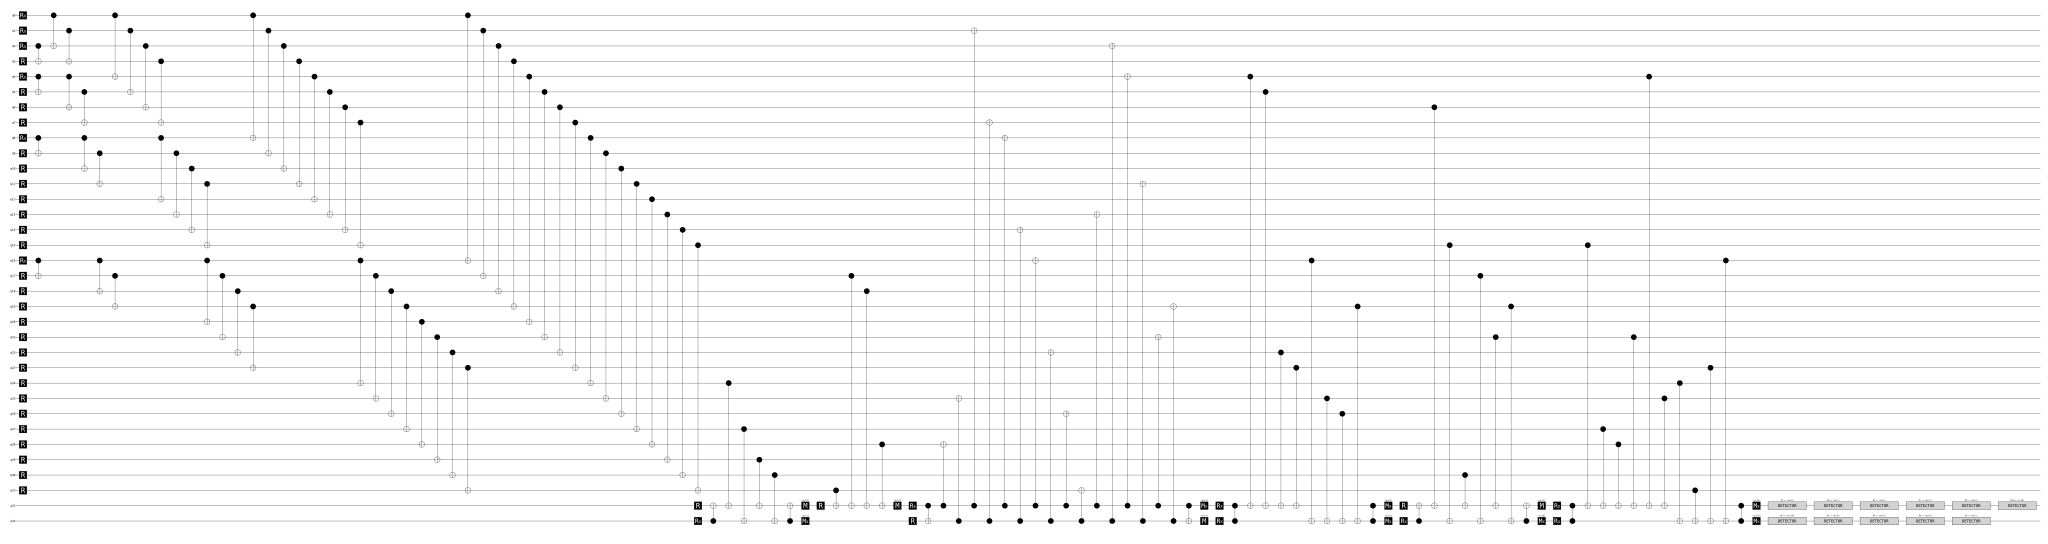

In [165]:
bens_circ = stim.Circuit("""
RX 0 1 2
R 3
RX 4
R 5 6 7
RX 8
R 9 10 11 12 13 14 15
RX 16
R 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31
CX 2 3 4 5 8 9 16 17 0 2 1 3 4 6 5 7 8 10 9 11 16 18 17 19 0 4 1 5 2 6 3 7 8 12 9 13 10 14 11 15 16 20 17 21 18 22 19 23 0 8 1 9 2 10 3 11 4 12 5 13 6 14 7 15 16 24 17 25 18 26 19 27 20 28 21 29 22 30 23 31 0 16 1 17 2 18 3 19 4 20 5 21 6 22 7 23 8 24 9 25 10 26 11 27 12 28 13 29 14 30 15 31
R 32
RX 33
CX 33 32 24 32 27 33 29 32 30 33 33 32
M 32
MX 33
R 32
CX 31 32 17 32 18 32 28 32
M 32
RX 32
R 33
CX 32 33 32 28 33 25 32 1 33 7 32 8 33 14 32 16 33 22 32 26 33 31 32 13 33 2 32 4 33 11 32 21 33 19 32 33
MX 32
M 33
RX 32
RX 33
CZ 33 32
CX 4 32 5 32 22 32 23 32
CX 16 33 25 33 26 33 19 33
CZ 33 32
MX 32
MX 33
R 32
RX 33
CX 33 32 6 32 15 33 30 32 17 33 21 32 19 33 33 32
M 32
MX 33
RX 32
RX 33
CZ 33 32
CX 15 32 27 32 28 32 21 32 4 32 25 32
CX 24 33 31 33 23 33 16 33
CZ 33 32
MX 32
MX 33
""")
for i in range(bens_circ.num_measurements):
    bens_circ.append("DETECTOR", [stim.target_rec(-i-1)])


print(f"Num CX: {count_operations(bens_circ)[0]}")
print(f"Num Meas: {count_operations(bens_circ)[1]}")
print(f"Total instructions: {sum(count_operations(bens_circ))}")
print(f"Depth: {get_circuit_depth(bens_circ)}")
bens_circ.diagram("timeline-svg")

In [166]:
circuit = bens_circ.copy()
circuit.append("M", range(H_z.shape[1]))
samples = circuit.compile_sampler().sample(10)
flags = samples[:, :-H_z.shape[1]]
meas_samples = samples[:, -H_z.shape[1]:]
print(flags.astype(int))
print(meas_samples @ H_z.T % 2)
print(meas_samples @ L_z.T % 2)

[[0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0]]
[[0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]]
[[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]]


In [167]:
print("\nRunning Fast DEM/SAT FT Verification...")
res_exhaustive = verify_ftsp(
    prep_circ=bens_circ,
    H_primary=H_z, L_primary=np.atleast_2d(L_z),
    H_conjugate=H_x, L_conjugate=np.atleast_2d(L_x),
    d=d, t=d // 2,
    primary_basis="Z", conjugate_basis="X",
    verbose=True
)
print("Verification Result:", res_exhaustive is True)


Running Fast DEM/SAT FT Verification...

  [Primary] Evaluating Z-basis via Combinatorics (d=4, t=2)...
    [PASS] No uncorrectable conjugate cascades found.

  [Conjugate] Evaluating X-basis via Combinatorics (t=2)...
    [PASS] No uncorrectable conjugate cascades found.
Verification Result: True


In [146]:
bens_circ = stim.Circuit("""
RX 0 1 2
R 3
RX 4
R 5 6 7
RX 8
R 9 10 11 12 13 14 15
RX 16
R 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32
RX 33
CX 2 3 4 5 8 9 16 17 0 2 1 3 4 6 5 7 8 10 9 11 16 18 17 19 0 4 1 5 2 6 3 7 8 12 9 13 10 14 11 15 16 20 17 21 18 22 19 23 0 8 1 9 2 10 3 11 4 12 5 13 6 14 7 15 16 24 17 25 18 26 19 27 20 28 21 29 22 30 23 31 0 16 1 17 2 18 3 19 4 20 5 21 6 22 7 23 8 24 9 25 10 26 11 27 12 28 13 29 14 30 15 31 33 32 24 32 27 33 29 32 30 33 33 32
M 32
MX 33
R 32
RX 33
CX 33 32 31 32 17 33 18 32 28 33 33 32
M 32
MX 33
RX 32
R 33
CX 32 33 32 28 33 25 32 1 33 7 32 8 33 14 32 16 33 22 32 26 33 31 32 13 33 2 32 4 33 11 32 21 33 19 32 33
MX 32
M 33
R 32
RX 33
CX 33 32 4 32 5 33 22 32 23 33 33 32
M 32
MX 33
R 32
RX 33
CX 33 32 16 32 25 33 26 32 19 33 33 32
M 32
MX 33
R 32
RX 33
CX 33 32 6 32 15 33 30 32 17 33 21 32 19 33 33 32
M 32
MX 33
R 32
RX 33
CX 33 32 15 32 27 33 28 32 21 33 4 32 25 33 33 32
M 32
MX 33
R 32
RX 33
CX 33 32 24 32 31 33 23 32 16 33 33 32
M 32
MX 33
""").diagram('timeline-svg')

In [80]:
print(res_exhaustive)

RX 2
R 3
RX 4
R 5
RX 8
R 9
RX 16
R 17 32
RX 33
CX 2 3 4 5 8 9 16 17 33 32
RX 0 1
R 6 7 10 11 18 19
CX 0 2 1 3 4 6 5 7 8 10 9 11 16 18 17 19
R 12 13 14 15 20 21 22 23
CX 0 4 1 5 2 6 3 7 8 12 9 13 10 14 11 15 16 20 17 21 18 22 19 23
R 24 25 26 27 28 29 30 31
CX 0 8 1 9 2 10 3 11 4 12 5 13 6 14 7 15 16 24 17 25 18 26 19 27 20 28 21 29 22 30 23 31 0 16 1 17 2 18 3 19 4 20 5 21 6 22 7 23 8 24 9 25 10 26 11 27 12 28 13 29 14 30 15 31 24 32 27 33 29 32 30 33 33 32
M 32
MX 33
R 32
RX 33
CX 33 32 31 32 17 33 18 32 28 33 33 32
M 32
MX 33
RX 32
R 33
CX 32 33 32 28 33 25 32 1 33 7 32 8 33 14 32 16 33 22 32 26 33 31 32 13 33 2 32 4 33 11 32 21 33 19 32 33
MX 32
M 33
R 32
CX 4 32 5 32 22 32 23 32
M 32
R 32
CX 16 32 25 32 26 32 19 32
M 32
R 32
RX 33
CX 33 32 6 32 15 33 30 32 17 33 21 32 19 33 33 32
M 32
MX 33
R 32
RX 33
CX 33 32 15 32 27 33 28 32 21 33 4 32 25 33 33 32
M 32
MX 33
R 32
CX 24 32 31 32
Z 32
CX 23 32 16 32
M 32
DETECTOR rec[-1]
DETECTOR rec[-2]
DETECTOR rec[-3]
DETECTOR rec[-4]
DETECTOR 

In [ ]:
print(final_circ)

In [ ]:
import stim

res_exhaustive = stim.Circuit("""
RX 0
R 1
RX 2 3
R 4 5
RX 6
R 7 8 9 10 11
RX 12
R 13 14 15 16
CX 0 16
RX 17
CX 17 8 16 4 0 5 6 7 3 10 2 14 12 15 16 9 6 11 3 13 2 17 12 8 16 17 17 8
MX 17
CX 0 16
M 16
DETECTOR rec[-2]
DETECTOR rec[-1]
TICK
CX 12 1 3 12 3 4 2 6 7 0 6 10 1 6 2 4 0 13 0 1 2 0 12 11 12 5 12 2 0 12
TICK
RX 16
CX 16 8
TICK
CX 16 9
TICK
CX 16 10
TICK
CX 16 11
TICK
CX 16 12
TICK
CX 16 13
TICK
CX 16 14
TICK
CX 16 15
TICK
MX 16
DETECTOR rec[-1]
# R 31
# TICK
# CX 12 31
# TICK
# R 30
# TICK
# CX 10 30
# TICK
# R 29
# TICK
# CX 8 29
# TICK
# R 28
# TICK
# CX 5 28
# RX 17
# R 16
# CX 17 16
# RX 19
# R 18
# CX 19 18
# RX 21
# R 20
# CX 21 20
# RX 23
# R 22
# CX 23 22
# RX 25
# R 24
# CX 25 24
# RX 27
# R 26
# CX 27 26 14 16 15 18 7 20 3 22 6 24
# TICK
# CX 12 16 6 18 5 20 8 22 1 26
# TICK
# CX 10 16 14 18 12 22 7 24 5 26
# TICK
# CX 8 16 12 20 7 22 2 24 14 26
# TICK
# CX 17 16
# MX 17
# DETECTOR rec[-1]
# M 16
# DETECTOR rec[-1]
# CX 23 22
# MX 23
# DETECTOR rec[-1]
# M 22
# DETECTOR rec[-1]
# CX 7 18 14 20 3 24 10 26
# TICK
# CX 19 18
# MX 19
# DETECTOR rec[-1]
# M 18
# DETECTOR rec[-1]
# CX 21 20
# MX 21
# DETECTOR rec[-1]
# M 20
# DETECTOR rec[-1]
# CX 25 24
# MX 25
# DETECTOR rec[-1]
# M 24
# DETECTOR rec[-1]
# CX 27 26
# MX 27
# DETECTOR rec[-1]
# M 26
# DETECTOR rec[-1]
# CX 5 28
# TICK
# M 28
# DETECTOR rec[-1]
# TICK
# CX 8 29
# TICK
# M 29
# DETECTOR rec[-1]
# TICK
# CX 10 30
# TICK
# M 30
# DETECTOR rec[-1]
# TICK
# CX 12 31
# TICK
# M 31
# DETECTOR rec[-1]
# TICK
# RX 17
# R 16
# CX 17 16 3 16
# TICK
# CX 5 16
# TICK
# CX 10 16
# TICK
# CX 12 16
# TICK
# CX 17 16
# MX 17
# DETECTOR rec[-1]
# M 16
# DETECTOR rec[-1]
""")

res_exhaustive.diagram('timeline-svg')

In [ ]:
with open("res_exhaustive.svg", "w") as f:
    f.write(str(res_exhaustive.diagram("timeline-svg")))